# Sprint-1

### Step 1: Data Collection & Loading
- Import dataset from: CSV / Excel / Database / API
- Load using appropriate tools (e.g., pandas)
- Validate:
  - Dataset size
  - Column structure


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings; warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("./bridge_data.csv")

In [3]:
df

,Age_of_Bridge,Traffic_Volume,Material_Type,Maintenance_Level,Bridge_Condition
0,80,60,Concrete,No-Maintainance,0
1,44,2516,Steel,Bi-Annual,0
2,61,4406,Concrete,Annual,1
3,93,2082,Steel,No-Maintainance,1
4,62,4159,Steel,No-Maintainance,0
...,...,...,...,...,...
715,6,2964,Concrete,Annual,0
716,90,3637,Concrete,No-Maintainance,0
717,42,2134,Concrete,Annual,0
718,92,778,Steel,No-Maintainance,0


In [4]:
df["Bridge_Condition"].value_counts()

Bridge_Condition
0    619
1    101
Name: count, dtype: int64

### Step 2: Initial Data Inspection
- Perform:
    - .head(), .tail()
    - .info()
    - .describe()
- Check:
    - Data types
    - Missing values
    - Unique values
    - Data consistency


In [5]:
df.head()

,Age_of_Bridge,Traffic_Volume,Material_Type,Maintenance_Level,Bridge_Condition
0,80,60,Concrete,No-Maintainance,0
1,44,2516,Steel,Bi-Annual,0
2,61,4406,Concrete,Annual,1
3,93,2082,Steel,No-Maintainance,1
4,62,4159,Steel,No-Maintainance,0


In [6]:
df.tail()

,Age_of_Bridge,Traffic_Volume,Material_Type,Maintenance_Level,Bridge_Condition
715,6,2964,Concrete,Annual,0
716,90,3637,Concrete,No-Maintainance,0
717,42,2134,Concrete,Annual,0
718,92,778,Steel,No-Maintainance,0
719,15,1391,Steel,Bi-Annual,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age_of_Bridge      720 non-null    int64
 1   Traffic_Volume     720 non-null    int64
 2   Material_Type      720 non-null    str  
 3   Maintenance_Level  720 non-null    str  
 4   Bridge_Condition   720 non-null    int64
dtypes: int64(3), str(2)
memory usage: 40.0 KB


## Observation
- There are `five columns` and `720 entries/rows`.
- There are `three numerical columns` and `two are categorical columns`.

In [8]:
df.describe()

,Age_of_Bridge,Traffic_Volume,Bridge_Condition
count,720.000000,720.000000,720.000000
mean,49.033333,2420.827778,0.140278
std,29.469467,1423.863663,0.347516
min,1.000000,51.000000,0.000000
25%,23.000000,1106.000000,0.000000
50%,49.000000,2377.000000,0.000000
75%,75.000000,3605.000000,0.000000
max,99.000000,4994.000000,1.000000


# Checking Missing values

In [9]:
df.isna().sum()

Age_of_Bridge        0
Traffic_Volume       0
Material_Type        0
Maintenance_Level    0
Bridge_Condition     0
dtype: int64

## Observation
- In the Bridge dataset, there is `no missing information/data`.

# Checking Unique values

In [10]:
df.columns

Index(['Age_of_Bridge', 'Traffic_Volume', 'Material_Type', 'Maintenance_Level',
       'Bridge_Condition'],
      dtype='str')

In [11]:
obj_col = df.select_dtypes(include="object").columns
obj_col

Index(['Material_Type', 'Maintenance_Level'], dtype='str')

In [12]:
for i in obj_col:
    print(f"{i}:",df[i].unique())
    print()

Material_Type: <ArrowStringArray>
['Concrete', 'Steel']
Length: 2, dtype: str

Maintenance_Level: <ArrowStringArray>
['No-Maintainance', 'Bi-Annual', 'Annual']
Length: 3, dtype: str



## Observation
- The `Material_Type` column contains `two unique` values.
- The `Maintenance_Level` column contains `three unique` values.

### Step 3: Data Cleaning
- Handle missing values: Drop / Impute (mean, median, mode)
- Remove duplicates
- Fix incorrect data types
- Standardize column names


## Handle missing values

In [13]:
(df.isnull().sum()/len(df))*100

Age_of_Bridge        0.0
Traffic_Volume       0.0
Material_Type        0.0
Maintenance_Level    0.0
Bridge_Condition     0.0
dtype: float64

## Observation
- There are no missing values in the dataset

## Remove duplicates

In [14]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
715     True
716     True
717     True
718     True
719     True
Length: 720, dtype: bool

In [15]:
df.duplicated().sum()

np.int64(128)

## Observation
- There are `128` duplicate rows in the dataset.

In [16]:
df.drop_duplicates(inplace = True,ignore_index=True)

In [17]:
df

,Age_of_Bridge,Traffic_Volume,Material_Type,Maintenance_Level,Bridge_Condition
0,80,60,Concrete,No-Maintainance,0
1,44,2516,Steel,Bi-Annual,0
2,61,4406,Concrete,Annual,1
3,93,2082,Steel,No-Maintainance,1
4,62,4159,Steel,No-Maintainance,0
...,...,...,...,...,...
587,36,1066,Steel,Bi-Annual,0
588,2,2763,Steel,No-Maintainance,0
589,35,2047,Steel,Bi-Annual,0
590,57,2780,Concrete,Annual,0


## Observation
- After deleting the duplicates. The dataset has `592 rows`.

## Fix incorrect data types

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 592 entries, 0 to 591
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age_of_Bridge      592 non-null    int64
 1   Traffic_Volume     592 non-null    int64
 2   Material_Type      592 non-null    str  
 3   Maintenance_Level  592 non-null    str  
 4   Bridge_Condition   592 non-null    int64
dtypes: int64(3), str(2)
memory usage: 33.0 KB


## Observations
- All columns contains correct datatypes.

## Standardize column names

In [19]:
df.columns

Index(['Age_of_Bridge', 'Traffic_Volume', 'Material_Type', 'Maintenance_Level',
       'Bridge_Condition'],
      dtype='str')

## Observation
- There is no problem with the column names.

### Step 4: Exploratory Data Analysis (EDA)
- Univariate Analysis
    - Distribution plots
    - Identify skewness
- Bivariate Analysis
    - Feature vs Target relationship
    - Correlation analysis
- Multivariate Analysis
    - Pairplots / heatmaps
    - Interaction effects


## Univariate

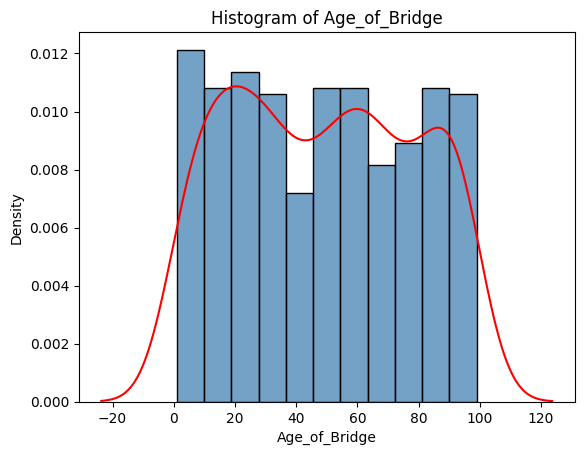

In [20]:
sns.histplot(
    x=df['Age_of_Bridge'],
    stat='density',
    color='steelblue'
)

sns.kdeplot(
    x=df['Age_of_Bridge'],
    color='red',
)

plt.title('Histogram of Age_of_Bridge')
plt.show()

## Observation
- The bridge age values are spread across different ranges.
- Most bridge ages are distributed evenly.

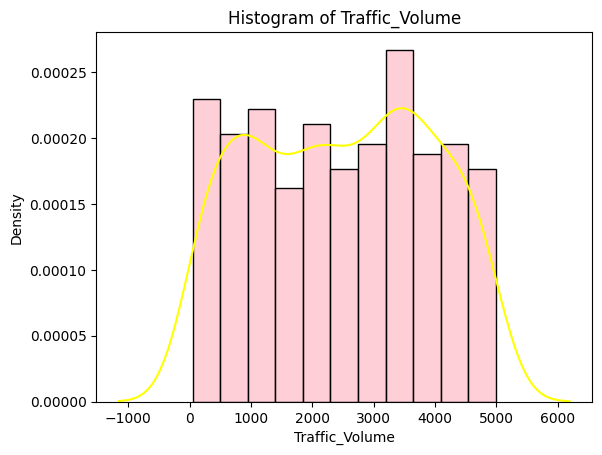

In [21]:
sns.histplot(
    x=df['Traffic_Volume'],
    stat='density',
    color='pink'
)

sns.kdeplot(
    x=df['Traffic_Volume'],
    color='yellow',
)

plt.title('Histogram of Traffic_Volume')
plt.show()

## Observation
- Traffic volume values are widely distributed.
- Some bridges have very high traffic compared to others.

In [22]:
num_cols = ['Age_of_Bridge', 'Traffic_Volume']
print(df[num_cols].skew())

Age_of_Bridge     0.051466
Traffic_Volume   -0.025843
dtype: float64


## Observation 
- `Age_of_Bridge` has Positive skewness(tail towards right side).
- `Traffic_Volume` has Negative skewness(tail towards left side).

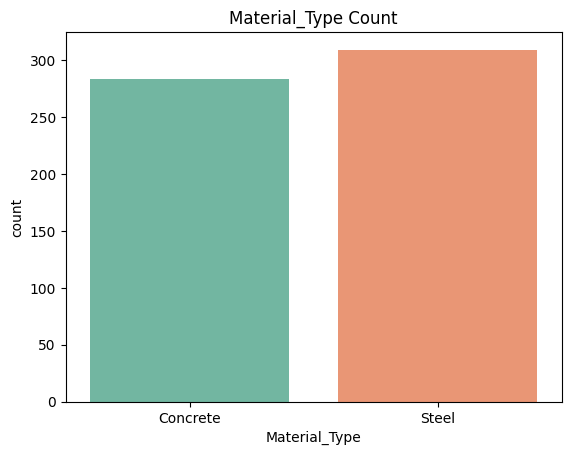

In [23]:
sns.countplot(x=df['Material_Type'], palette='Set2')
plt.title('Material_Type Count')
plt.show()

## Observation
- Most of the bridges Constructed with `Steel`

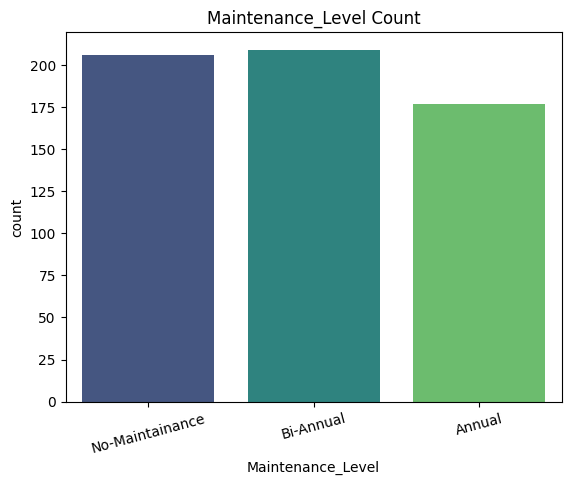

In [24]:
sns.countplot(x=df['Maintenance_Level'], palette='viridis')
plt.title('Maintenance_Level Count')
plt.xticks(rotation=15)
plt.show()

## Observation
- The `Bi-Annual` maintenance level has the highest frequency among the bridges.

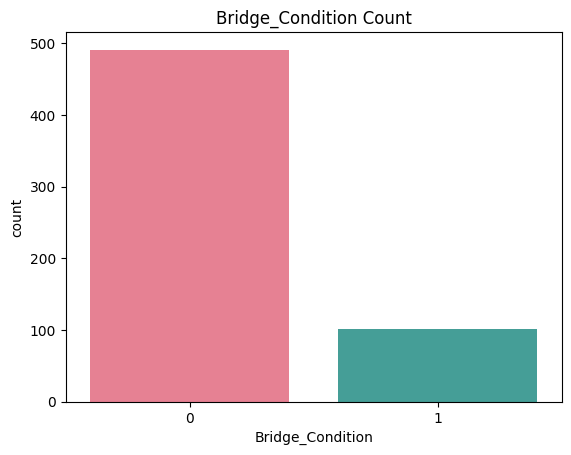

In [25]:
sns.countplot(x=df['Bridge_Condition'], palette='husl')
plt.title('Bridge_Condition Count')
plt.show()

## Observation
- Most of the bridges are `Poor/Unsafe condition`.
- Data is `imbalanced`.

## Bivariate

### Feature vs Target Relationship

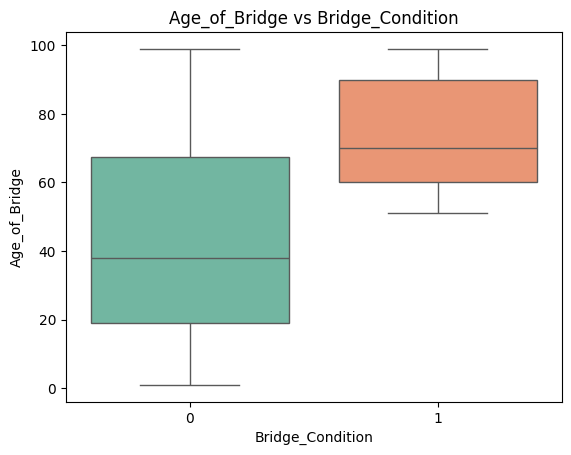

In [26]:
sns.boxplot(x='Bridge_Condition', y='Age_of_Bridge', data=df, palette="Set2")
plt.title('Age_of_Bridge vs Bridge_Condition')
plt.show()

## Observation
- Older bridges may show different condition levels.

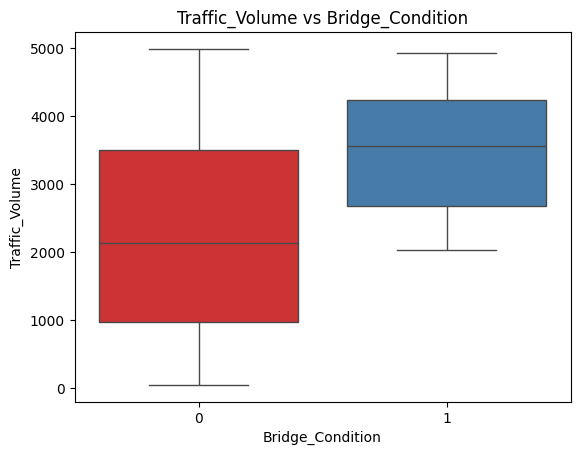

In [27]:
sns.boxplot(x='Bridge_Condition', y='Traffic_Volume', data=df, palette="Set1")
plt.title('Traffic_Volume vs Bridge_Condition')
plt.show()

## Observation
- Variation in traffic can influence bridge condition.

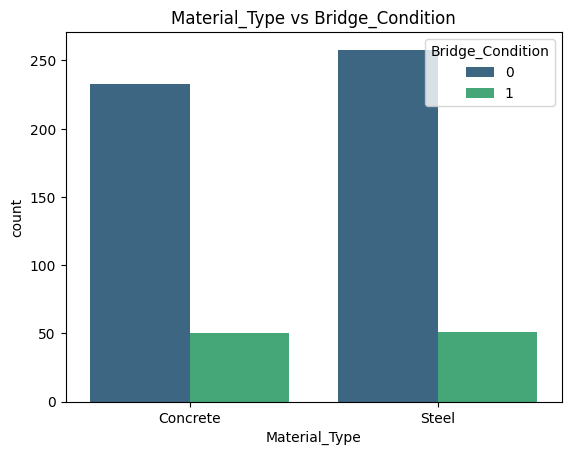

In [28]:
sns.countplot(x='Material_Type', hue='Bridge_Condition', data=df, palette="viridis")
plt.title('Material_Type vs Bridge_Condition')
plt.show()

## Observation
- Most of the steel Bridges are in poor condition.

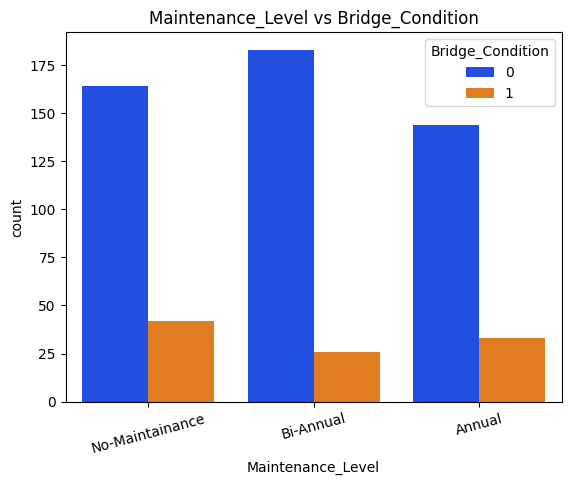

In [29]:
sns.countplot(x='Maintenance_Level', hue='Bridge_Condition', data=df, palette="bright")
plt.title('Maintenance_Level vs Bridge_Condition')
plt.xticks(rotation=15)
plt.show()

## Observation
- `Bi-Annual` maintanance bridges having more poor bridges compare to others.

## Multivariate

## Correlation Analysis

### Convert Categorical Columns into Numerical

In [30]:
le = LabelEncoder()
encoded_df = df.copy()
encoded_df['Material_Type'] = le.fit_transform(encoded_df['Material_Type'])
encoded_df['Maintenance_Level'] = le.fit_transform(encoded_df['Maintenance_Level'])

In [31]:
corr = encoded_df.corr()
print(corr)

                   Age_of_Bridge  Traffic_Volume  Material_Type  \
Age_of_Bridge           1.000000        0.010247       0.006697   
Traffic_Volume          0.010247        1.000000      -0.044678   
Material_Type           0.006697       -0.044678       1.000000   
Maintenance_Level       0.059796        0.021892      -0.038485   
Bridge_Condition        0.385439        0.319409      -0.015444   

                   Maintenance_Level  Bridge_Condition  
Age_of_Bridge               0.059796          0.385439  
Traffic_Volume              0.021892          0.319409  
Material_Type              -0.038485         -0.015444  
Maintenance_Level           1.000000          0.022666  
Bridge_Condition            0.022666          1.000000  


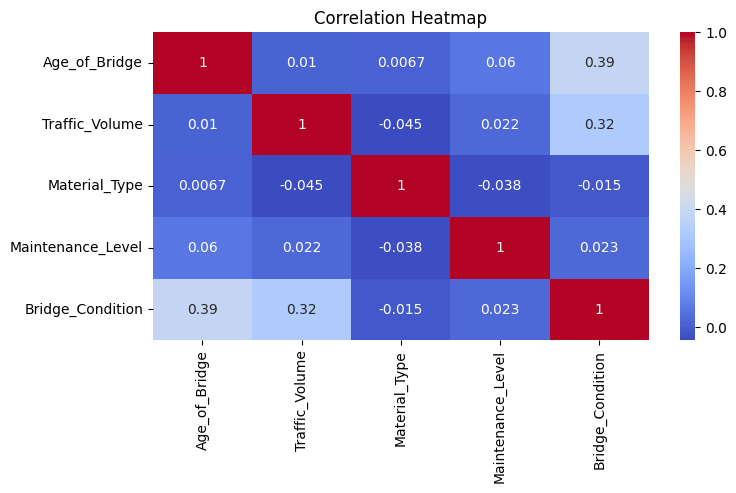

In [32]:
plt.figure(figsize=(8,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Observation
- `Bridge_Condition` is mainly depends on `Age_of_Bridge` and `Traffic_Volume` columns.

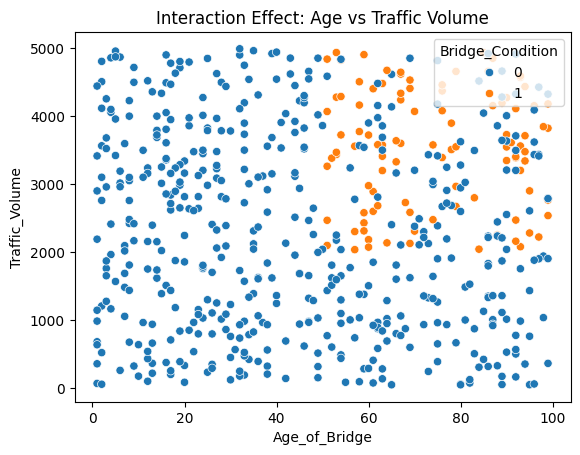

In [33]:
sns.scatterplot(
    x='Age_of_Bridge',
    y='Traffic_Volume',
    hue='Bridge_Condition',
    data=df
)

plt.title('Interaction Effect: Age vs Traffic Volume')
plt.show()

## Observation
- High traffic Bridges are poor in condition.

## Step 5: Outlier Detection & Treatment
- Use: Boxplots, IQR / Z-score
- Actions: Remove / Cap / Transform

In [34]:
df.columns

Index(['Age_of_Bridge', 'Traffic_Volume', 'Material_Type', 'Maintenance_Level',
       'Bridge_Condition'],
      dtype='str')

In [35]:
df.describe()

,Age_of_Bridge,Traffic_Volume,Bridge_Condition
count,592.000000,592.000000,592.000000
mean,48.937500,2484.121622,0.170608
std,29.469267,1438.735130,0.376484
min,1.000000,51.000000,0.000000
25%,23.000000,1165.250000,0.000000
50%,49.000000,2488.000000,0.000000
75%,75.000000,3656.000000,0.000000
max,99.000000,4994.000000,1.000000


In [36]:
def find_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = column[(column < lower) | (column > upper)]
    return outliers

In [37]:
find_outliers_iqr(df["Age_of_Bridge"])

Series([], Name: Age_of_Bridge, dtype: int64)

In [38]:
find_outliers_iqr(df["Traffic_Volume"])

Series([], Name: Traffic_Volume, dtype: int64)

## Observation
- By using `describe() and IQR method` we can conclude that there are no outliers in the data.

## Step 6: Feature Encoding
- Convert categorical → numerical:
    - Label Encoding
    - One-Hot Encoding


## One-Hot Encoding

In [39]:
df = pd.get_dummies(df, columns=['Material_Type', 'Maintenance_Level'],  dtype=int)

In [40]:
df.head()

,Age_of_Bridge,Traffic_Volume,Bridge_Condition,Material_Type_Concrete,Material_Type_Steel,Maintenance_Level_Annual,Maintenance_Level_Bi-Annual,Maintenance_Level_No-Maintainance
0,80,60,0,1,0,0,0,1
1,44,2516,0,0,1,0,1,0
2,61,4406,1,1,0,1,0,0
3,93,2082,1,0,1,0,0,1
4,62,4159,0,0,1,0,0,1


## Step 7: Feature Scaling
- Apply: Standardization / Normalization
- Important: Fit only on training data


In [41]:
X = df.drop('Bridge_Condition', axis=1)
y = df['Bridge_Condition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [42]:
scaler = StandardScaler()

In [43]:
df.columns

Index(['Age_of_Bridge', 'Traffic_Volume', 'Bridge_Condition',
       'Material_Type_Concrete', 'Material_Type_Steel',
       'Maintenance_Level_Annual', 'Maintenance_Level_Bi-Annual',
       'Maintenance_Level_No-Maintainance'],
      dtype='str')

In [44]:
num_cols = ['Age_of_Bridge', 'Traffic_Volume']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.head()

,Age_of_Bridge,Traffic_Volume,Material_Type_Concrete,Material_Type_Steel,Maintenance_Level_Annual,Maintenance_Level_Bi-Annual,Maintenance_Level_No-Maintainance
128,0.371099,-0.204453,0,1,0,1,0
386,1.395192,-0.305853,1,0,0,0,1
59,0.029734,-0.305144,1,0,1,0,0
497,1.600011,-0.418599,0,1,1,0,0
184,-0.038539,-0.150562,0,1,0,0,1


## Step 8: Train-Test Split
- Split dataset:
    - 70–80% Training
    - 20–30% Testing



In [45]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((473, 7), (119, 7), (473,), (119,))

In [46]:
df.head()

,Age_of_Bridge,Traffic_Volume,Bridge_Condition,Material_Type_Concrete,Material_Type_Steel,Maintenance_Level_Annual,Maintenance_Level_Bi-Annual,Maintenance_Level_No-Maintainance
0,80,60,0,1,0,0,0,1
1,44,2516,0,0,1,0,1,0
2,61,4406,1,1,0,1,0,0
3,93,2082,1,0,1,0,0,1
4,62,4159,0,0,1,0,0,1


In [47]:
df.to_csv("final_bridge_data", index=False)